
#  <span style="color:red">ASMAE AIT OUALI</span>

##  <span style="color:blue">  Modélisation de la Performance des Étudiants avec Régression </span>

##  Objectif du projet

L’objectif de ce projet est de modéliser et de prédire la performance académique des étudiants, représentée par la variable cible $y = \text{overall\_score}$, à partir d’un ensemble de variables explicatives issues du dataset.

Afin de mieux comprendre les mécanismes internes des algorithmes de machine learning, plusieurs modèles de régression sont implémentés **from scratch**, sans recours à des bibliothèques spécialisées telles que scikit-learn.

Les modèles étudiés sont :

- Régression linéaire simple  
- Régression linéaire multiple  
- Régression polynomiale  


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# CHARGEMENT
df = pd.read_csv(r"C:\Users\majid\Downloads\Student_Performance.csv")

df.head()

,student_id,age,gender,school_type,parent_education,study_hours,attendance_percentage,internet_access,travel_time,extra_activities,study_method,math_score,science_score,english_score,overall_score,final_grade
0,1,14,male,public,post graduate,3.1,84.3,yes,<15 min,yes,notes,42.7,55.4,57.0,53.1,e
1,2,18,female,public,graduate,3.7,87.8,yes,>60 min,no,textbook,57.6,68.8,64.8,61.3,d
2,3,17,female,private,post graduate,7.9,65.5,no,<15 min,no,notes,84.8,95.0,79.2,89.6,b
3,4,16,other,public,high school,1.1,58.1,no,15-30 min,no,notes,44.4,27.5,54.7,41.6,e
4,5,16,female,public,high school,1.3,61.0,yes,30-60 min,yes,group study,8.9,32.7,30.0,25.4,f


In [2]:
#  NETTOYAGE
# Supprimer colonnes inutiles
df = df.drop(columns=["student_id", "final_grade"])

# Transformer variables catégorielles en numériques
df = pd.get_dummies(df, drop_first=True)

#  forcer tout en float
df = df.astype(float)

# Vérification
print(df.dtypes)



age                               float64
study_hours                       float64
attendance_percentage             float64
math_score                        float64
science_score                     float64
english_score                     float64
overall_score                     float64
gender_male                       float64
gender_other                      float64
school_type_public                float64
parent_education_graduate         float64
parent_education_high school      float64
parent_education_no formal        float64
parent_education_phd              float64
parent_education_post graduate    float64
internet_access_yes               float64
travel_time_30-60 min             float64
travel_time_<15 min               float64
travel_time_>60 min               float64
extra_activities_yes              float64
study_method_group study          float64
study_method_mixed                float64
study_method_notes                float64
study_method_online videos        

In [3]:
# SÉPARATION X / y
X = df.drop("overall_score", axis=1).values
y = df["overall_score"].values.reshape(-1, 1)

# TRAIN / TEST SPLIT
def train_test_split(X, y, test_size=0.2):
    np.random.seed(42)
    indices = np.random.permutation(len(X))
    
    test_size = int(len(X) * test_size)
    
    test_idx = indices[:test_size]
    train_idx = indices[test_size:]
    
    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]

X_train, X_test, y_train, y_test = train_test_split(X, y)



In [4]:
# NORMALISATION
def normalize(X_train, X_test):
    # calcul uniquement sur TRAIN
    mean = np.mean(X_train, axis=0)
    std = np.std(X_train, axis=0)
    # éviter division par 0
    std[std == 0] = 1
     # normalisation
    X_train = (X_train - mean) / std
    X_test = (X_test - mean) / std
    
    return X_train, X_test

X_train, X_test = normalize(X_train, X_test)

#  <span style="color:blue">Régression linéaire simple FROM SCRATCH</span>
#  Régression Linéaire Simple

##  Définition

La régression linéaire simple modélise la relation entre une variable explicative $x$ et une variable cible $y$ en supposant une relation linéaire.

##  Formulation mathématique

$$
y = ax + b
$$

où :

- $a \in \mathbb{R}$ est le coefficient directeur (pente)  
- $b \in \mathbb{R}$ est le biais (ordonnée à l’origine)



In [5]:
# RÉGRESSION LINÉAIRE SIMPLE FROM SCRATCH

# On reprend df AVANT séparation X_train
# Choisir UNE variable explicative
X_simple = df["study_hours"].values

# Variable cible
y_simple = df["overall_score"].values




In [6]:

#  CALCUL DES PARAMÈTRES (a et b)

# Moyennes
x_mean = np.mean(X_simple)
y_mean = np.mean(y_simple)

# Calcul de la pente (a)
# formule : covariance / variance
numerateur = np.sum((X_simple - x_mean) * (y_simple - y_mean))
denominateur = np.sum((X_simple - x_mean) ** 2)

a = numerateur / denominateur

# Calcul du biais (b)
b = y_mean - a * x_mean

print("\nParamètres du modèle :")
print("a (pente) =", a)
print("b (biais) =", b)



Paramètres du modèle :
a (pente) = 7.9113083102691135
b (biais) = 30.357605623363966


In [7]:
# FONCTION DE PRÉDICTION

def predict(x):
    """
    Applique la formule y = ax + b
    """
    return a * x + b



# 4. PRÉDICTIONS

y_pred_simple = predict(X_simple)





In [8]:
#  MÉTRIQUES (from scratch)

def mse(y, y_pred):
    return np.mean((y - y_pred) ** 2)

def rmse(y, y_pred):
    return np.sqrt(mse(y, y_pred))

def r2_score(y, y_pred):
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    return 1 - (ss_res / ss_tot)

print("\n=== RÉGRESSION LINÉAIRE ===")
print("MSE :", mse(y_simple, y_pred_simple))
print("RMSE :", rmse(y_simple, y_pred_simple))
print("R² :", r2_score(y_simple, y_pred_simple))



=== RÉGRESSION LINÉAIRE ===
MSE : 64.36208280231206
RMSE : 8.022598257566688
R² : 0.8204219113179974


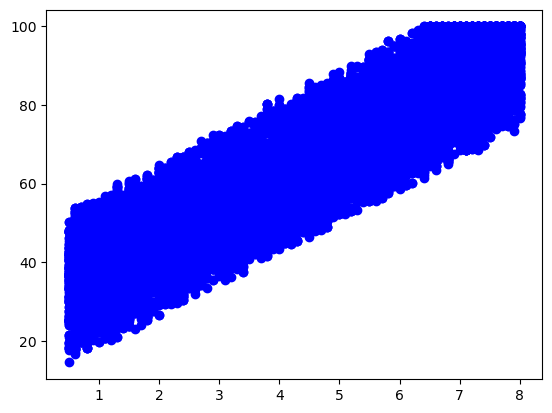

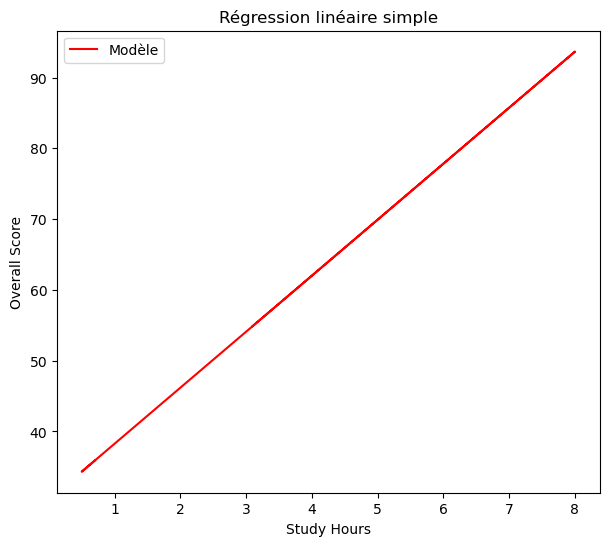

In [9]:
# 6. VISUALISATION DU MODÈLE
plt.scatter(X_simple, y_simple, color="blue", label="Données réelles")
plt.figure(figsize=(7,6))
# ligne de régression
plt.plot(X_simple, y_pred_simple, color="red", label="Modèle")

plt.xlabel("Study Hours")
plt.ylabel("Overall Score")
plt.title("Régression linéaire simple")
plt.legend()

plt.show()

#  <span style="color:blue">Régression multiple  FROM SCRATCH</span>
#  2. Régression Linéaire Multiple

##  Définition

La régression linéaire multiple permet d’utiliser plusieurs variables explicatives pour prédire la variable cible.

##  Formulation mathématique

$$
\hat{y} = Xw + b
$$

ou encore :

$$
\hat{y} = w_1 x_1 + w_2 x_2 + \cdots + w_n x_n + b
$$

où :

- $X \in \mathbb{R}^{m \times n}$ est la matrice des features  
- $w \in \mathbb{R}^{n}$ est le vecteur des coefficients  
- $b \in \mathbb{R}$ est le biais  
- $m$ : nombre d’échantillons  
- $n$ : nombre de variables  

##  Fonction de coût

$$
J(w, b) = \frac{1}{m} \sum_{i=1}^{m} (\hat{y}_i - y_i)^2
$$

##  Gradient Descent

Les paramètres sont mis à jour ainsi :

$$
w := w - \alpha \frac{\partial J}{\partial w}
$$

$$
b := b - \alpha \frac{\partial J}{\partial b}
$$

Les gradients sont :

$$
\frac{\partial J}{\partial w} = \frac{2}{m} X^T (Xw + b - y)
$$
$$
\frac{\partial J}{\partial b} = \frac{2}{m} \sum_{i=1}^{m} (\hat{y}_i - y_i)
$$


In [10]:
# INITIALISATION DES PARAMÈTRES

def initialize_params(n_features):
    """
    n_features = nombre de variables explicatives
    
    w = vecteur de poids (coefficients)
    b = biais (intercept)
    """
    w = np.zeros((n_features, 1))  # initialisation à 0
    b = 0
    return w, b

In [11]:
# FONCTION DE COÛT

def compute_cost(X, y, w, b):
    """
    Calcule l'erreur du modèle
    
    MSE = moyenne des erreurs au carré
    """
    m = len(y)
    
    # prédictions
    y_pred = X.dot(w) + b
    
    # calcul du coût
    cost = (1/m) * np.sum((y_pred - y) ** 2)
    
    return cost

In [12]:
# CALCUL DES GRADIENTS
def compute_gradients(X, y, w, b):
    """
    Calcule comment ajuster w et b
    """
    m = len(y)
    
    # prédictions actuelles
    y_pred = X.dot(w) + b
    
    # gradient pour w
    dw = (2/m) * X.T.dot(y_pred - y)
    
    # gradient pour b
    db = (2/m) * np.sum(y_pred - y)
    
    return dw, db

In [13]:
# GRADIENT DESCENT
def gradient_descent(X, y, lr=0.001, epochs=1000):
    """
    Apprentissage du modèle :
    on ajuste progressivement les paramètres
    """
    
    # initialisation
    w, b = initialize_params(X.shape[1])
    
    costs = []  # stocker l'évolution du coût
    
    for i in range(epochs):
        
        # calcul du gradient
        dw, db = compute_gradients(X, y, w, b)
        
        # mise à jour des paramètres
        w = w - lr * dw
        b = b - lr * db
        
        # calcul du coût
        cost = compute_cost(X, y, w, b)
        costs.append(cost)
        
        # sécurité anti divergence
        if np.isnan(cost) or np.isinf(cost):
            print(" Divergence détectée à l'epoch", i)
            break
        
        # affichage
        if i % 100 == 0:
            print(f"Epoch {i} | Cost: {cost}")
    
    return w, b, costs

In [14]:
# ENTRAÎNEMENT
w, b, costs = gradient_descent(X_train, y_train, lr=0.001, epochs=1000)

Epoch 0 | Cost: 4434.5220416437005
Epoch 100 | Cost: 2838.318582264158
Epoch 200 | Cost: 1873.0451432335713
Epoch 300 | Cost: 1252.455650560295
Epoch 400 | Cost: 843.1893581055241
Epoch 500 | Cost: 570.5843151297313
Epoch 600 | Cost: 388.3091569276395
Epoch 700 | Cost: 266.24894068714343
Epoch 800 | Cost: 184.45880731690195
Epoch 900 | Cost: 129.63340082174582


In [15]:
#  PRÉDICTION
def predict(X, w, b):
    """
    Prédire les valeurs
    """
    return X.dot(w) + b

y_pred = predict(X_test, w, b)

In [16]:
# MÉTRIQUES
def mse(y, y_pred):
    return np.mean((y - y_pred)**2)

def rmse(y, y_pred):
    return np.sqrt(mse(y, y_pred))

def r2_score(y, y_pred):
    ss_res = np.sum((y - y_pred)**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    return 1 - (ss_res / ss_tot)
print("\n=== multiple Regression ===")
print("MSE:", mse(y_test, y_pred))
print("RMSE:", rmse(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))


=== multiple Regression ===
MSE: 94.54686259942379
RMSE: 9.723521100888494
R2: 0.7395914295074393


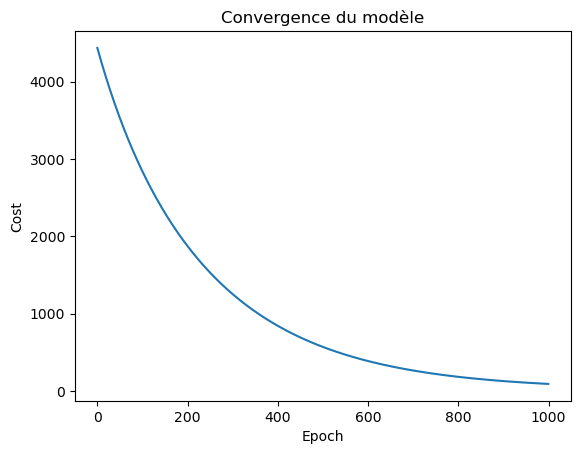

In [17]:
plt.plot(costs)
plt.title("Convergence du modèle")
plt.xlabel("Epoch")
plt.ylabel("Cost")
plt.show()

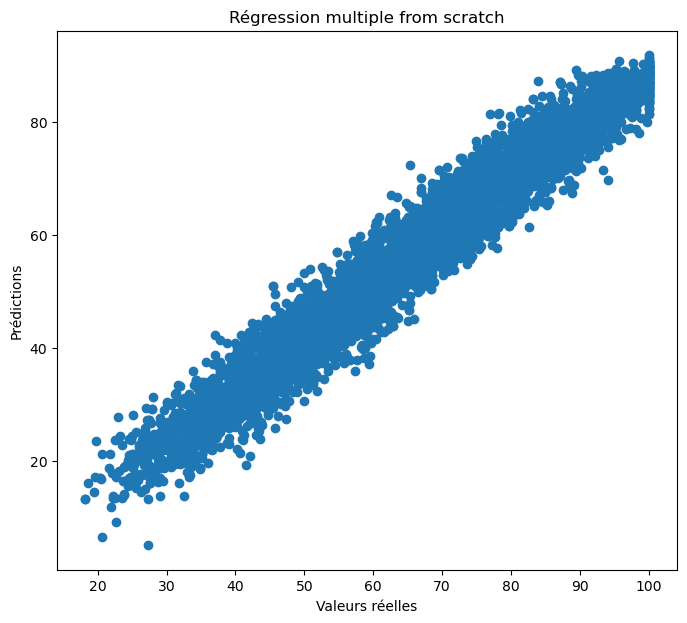

In [18]:
plt.figure(figsize=(8,7))
plt.scatter(y_test, y_pred)
plt.xlabel("Valeurs réelles")
plt.ylabel("Prédictions")
plt.title("Régression multiple from scratch")
plt.show()

#  <span style="color:blue">Régression polynomiale FROM SCRATCH</span>

#  3. Régression Polynomiale

##  Définition

La régression polynomiale permet de modéliser des relations non linéaires en introduisant des puissances des variables.

##  Formulation mathématique

$$
y = a_0 + a_1 x + a_2 x^2 + a_3 x^3 + \cdots + a_d x^d
$$

où $d$ est le degré du polynôme.

##  Transformation des données

$$
X \rightarrow [x, x^2, x^3, \dots, x^d]
$$

Après transformation, le modèle devient une régression linéaire dans un espace de dimension supérieure.


In [19]:
# TRANSFORMATION POLYNOMIALE

def polynomial_features(X, degree=2):
    """
    Crée des nouvelles variables :
    X, X^2, X^3, ..., X^degree
    """
    
    X_poly = X.copy()
    
    # Ajouter puissances
    for d in range(2, degree + 1):
        X_poly = np.concatenate((X_poly, X ** d), axis=1)
    
    return X_poly

In [20]:
# Transformer train et test
X_train_poly = polynomial_features(X_train, degree=2)
X_test_poly = polynomial_features(X_test, degree=2)

print("Shape original:", X_train.shape)
print("Shape polynomial:", X_train_poly.shape)

Shape original: (20000, 24)
Shape polynomial: (20000, 48)


In [21]:
# entraînement
w_poly, b_poly, costs_poly = gradient_descent(
    X_train_poly, y_train, lr=0.001, epochs=1000
)

Epoch 0 | Cost: 4055.2337370599234
Epoch 100 | Cost: 215.768429055978
Epoch 200 | Cost: 121.51719933892876
Epoch 300 | Cost: 92.18465321919638
Epoch 400 | Cost: 79.33007450834931
Epoch 500 | Cost: 71.17133389158626
Epoch 600 | Cost: 64.7533187917158
Epoch 700 | Cost: 59.27813894997655
Epoch 800 | Cost: 54.48621694443209
Epoch 900 | Cost: 50.25912461109692


In [22]:
def predict(X, w, b):
    return X.dot(w) + b

y_pred_poly = predict(X_test_poly, w_poly, b_poly)

In [23]:
print("\n=== Polynomial Regression ===")
print("MSE:", mse(y_test, y_pred_poly))
print("RMSE:", rmse(y_test, y_pred_poly))
print("R2:", r2_score(y_test, y_pred_poly))


=== Polynomial Regression ===
MSE: 48.70531819949611
RMSE: 6.97891955817633
R2: 0.8658518967313318


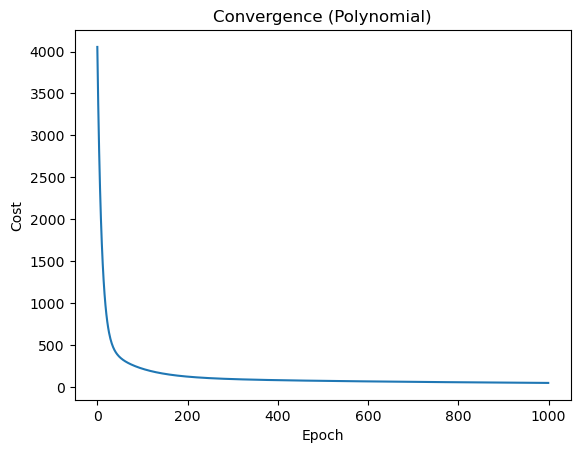

In [24]:
plt.plot(costs_poly)
plt.title("Convergence (Polynomial)")
plt.xlabel("Epoch")
plt.ylabel("Cost")
plt.show()

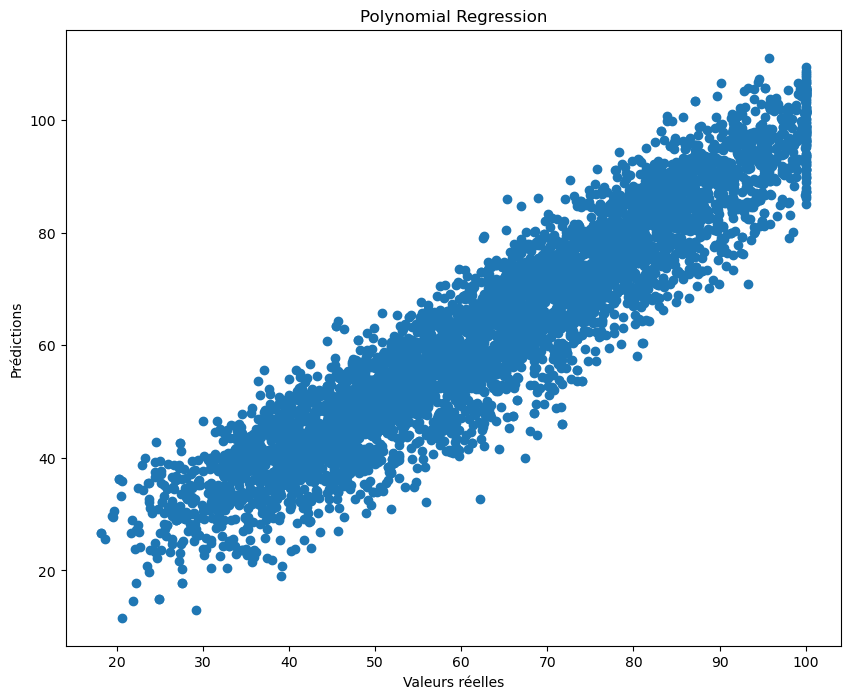

In [25]:
plt.figure(figsize=(10,8))
plt.scatter(y_test, y_pred_poly)
plt.xlabel("Valeurs réelles")
plt.ylabel("Prédictions")
plt.title("Polynomial Regression")
plt.show()

# Conclusion

- La régression linéaire simple permet d’étudier une relation univariée.  
- La régression linéaire multiple exploite plusieurs variables explicatives pour améliorer la prédiction.  
- La régression polynomiale permet de capturer des relations non linéaires.  

Ces modèles, implémentés from scratch, permettent de comprendre en profondeur :
- la structure mathématique des modèles  
- le rôle des fonctions de coût  
- le fonctionnement de l’optimisation par descente de gradient  

Ils constituent une base essentielle en machine learning et deep learning.